In [67]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import pybedtools
import os
import glob
from collections import defaultdict, Counter
from pathlib import Path
import itertools
from biodata.delimited import DelimitedWriter
import numpy as np
from biodatatools.utils.common import json_load
from matplotlib.font_manager import FontProperties

In [2]:
matplotlib.font_manager.fontManager.addfont(f"{Path.cwd().parent}/font/Arial.ttf")
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9

In [3]:
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_d2 = "/home/yc2553/databases/GEO/GSE179545/"
PROJECT_DIR_r = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"
PROJECT_DIR_s = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/"

# Data preparation

In [5]:
s = "HCT116"
ps = ["divergent", "unidirectional"]
ds = ["distal", "proximal"]
conditions = ["untreated", "treated"]

In [6]:
factor = "CTCF"
tss_labels = json_load(f"{PROJECT_DIR_o}labels/{s}_{factor}_DE.json")
motifs = json_load(f"{PROJECT_DIR_o}FIMO/{s}_{factor}_pos.json")

In [7]:
es = defaultdict(set)
for p, d in itertools.product(ps, ds):
	b = pybedtools.BedTool(f"{PROJECT_DIR_d}bed_plot/{s}_{p}_{d}.bed")
	es[(p,d)] = ["_".join(i.fields[:3]) for i in b]

In [8]:
# Get all loop anchors (10kb bins)

bin_size = 10000
loops = {}
for k in conditions:
	loops[k] = defaultdict(list)
	b = pybedtools.BedTool(f"{PROJECT_DIR_d2}FitHiChIP/loops/{k}/FitHiChIP_Peak2ALL_b{bin_size}_L20000_U2000000/P2PBckgr_0/Coverage_Bias/FitHiC_BiasCorr/Merge_Nearby_Interactions/FitHiChIP.interactions_FitHiC_Q0.01_MergeNearContacts_IGV.bedpe")
	anchors = set()
	for i in b:
		new_anchors = []
		chrom1, start1, end1, chrom2, start2, end2 = i.fields[:6]
		for chrom, start, end in [[chrom1, start1, end1], [chrom2, start2, end2]]:
			midpoint = (int(start)+int(end))//2
			new_start = str(midpoint-bin_size//2)
			new_end = str(midpoint+bin_size//2)
			new_anchors.append("_".join([chrom, new_start, new_end]))
		loops[k][new_anchors[0]].append(new_anchors[1])
		loops[k][new_anchors[1]].append(new_anchors[0])
		anchors |= set(new_anchors)

	outputfile = f"{PROJECT_DIR_o}temp/{k}_loop_anchors.bed"
	with DelimitedWriter(outputfile) as dw:
		for anchor in anchors:
			dw.write(anchor.split("_"))
	pybedtools.BedTool(outputfile).sort().saveas(outputfile)

In [9]:
# Assign PRO-cap elements to loop anchors (fully embedded)

results = []
mapping = {}
for p, d in itertools.product(ps, ds):
	mapping[(p,d)] = defaultdict(dict)
	b1 = pybedtools.BedTool(f"{PROJECT_DIR_d}bed_plot/{s}_{p}_{d}.bed")
	row = [len(b1)]
	for k in conditions:
		b2 = pybedtools.BedTool(f"{PROJECT_DIR_o}temp/{k}_loop_anchors.bed")
		overlaps = b1.intersect(b2, wao=True, f=1)
		for i in overlaps:
			if int(i.fields[-1]) > 0:
				e = "_".join(i.fields[:3])
				anchor = "_".join(i.fields[-4:-1])
				mapping[(p,d)][k][e] = anchor
		row.append(len(mapping[(p,d)][k]))
	results.append(row)
pd.DataFrame(results, columns=["No. elements"]+[f"No. elements with loops ({k})" for k in conditions], index=[(p,d) for p, d in itertools.product(ps, ds)])

,No. elements,No. elements with loops (untreated),No. elements with loops (treated)
"(divergent, distal)",8377,4062,1634
"(divergent, proximal)",8264,4462,1510
"(unidirectional, distal)",1444,492,113
"(unidirectional, proximal)",373,159,48


In [10]:
# Differentially expressed genes

DE_genes = {}
inputfile = f"{PROJECT_DIR_r}other/GSE179545/RNA_DEseq2_R.txt"
df = pd.read_table(inputfile)
for index, row in df.iterrows():
	if row["padj"] < 0.05 and abs(row["log2FoldChange"]) >= np.log2(1.5):
		label = "Up" if row["log2FoldChange"] > 0 else "Down"
	else:
		label = "Unchanged"
	DE_genes[index.split(".")[0]] = label

In [11]:
Counter([DE_genes[g] for g in DE_genes])

Counter({'Unchanged': 57121, 'Up': 485, 'Down': 214})

# Distal elements

In [12]:
# Distal elements changed from unidirectional to divergent transcription

p = "unidirectional"
d = "distal"
t = "minTSS"
es_keep = [e for e in es[(p,d)] if e in tss_labels[t] and tss_labels[t][e]=="Up" and e in motifs]
len(es_keep)

44

In [13]:
for k in conditions:
	es2 = [e for e in es_keep if e in mapping[(p,d)][k]]
	print(k, 
		  # No. elements with significant loops
		  len(es2), 
		  # No. loops per elements
		  np.mean([len(loops[k][mapping[(p,d)][k][e]]) for e in es2]))

untreated 22 2.772727272727273
treated 5 1.6


In [14]:
# Four elements experience both gains and losses of loops
# One element, which had no loops before treatment, gained a new loop

es_with_loops = set(mapping[(p,d)]["treated"]) & set(es_keep)
for e in es_with_loops:
	if e in mapping[(p,d)]["untreated"]:
		anchor1 = mapping[(p,d)]["untreated"][e]
		loops1 = loops["untreated"][anchor1]
	else:
		loops1 = []
	anchor2 = mapping[(p,d)]["treated"][e]
	loops2 = loops["treated"][anchor2]
	print(e, len(loops1), len(loops2), len(set(loops1) & set(loops2)))

chr4_56800039_56800540 3 1 0
chr22_41666589_41667090 5 2 0
chr19_17346103_17346604 2 1 0
chr14_49861939_49862440 9 3 1
chr17_49880439_49880940 0 1 0


In [15]:
# Check if new gains overlap with differential loops

inputfile = f"{PROJECT_DIR_d2}FitHiChIP/differential_loops/EdgeR_Loops_ALL/Loops_EdgeR_Default_SIG.bed"
df = pd.read_table(inputfile)

e = "chr17_49880439_49880940"
anchor = mapping[(p,d)]["treated"][e]
loop = loops["treated"][anchor][0]
chrom = e.split("_")[0]
start_min = np.min([int(anchor.split("_")[1]), int(loop.split("_")[1])])
start_max = np.max([int(anchor.split("_")[1]), int(loop.split("_")[1])])
df[(df["chr1"]==chrom) & (df["start1"]==int(start_min)) & (df["start2"]==int(start_max))]

,chr1,start1,end1,chr2,start2,end2,untreated_rep1_RawCC,untreated_rep1_QVal,untreated_rep2_RawCC,untreated_rep2_QVal,treated_rep1_RawCC,treated_rep1_QVal,treated_rep2_RawCC,treated_rep2_QVal,logFC,logCPM,PValue,FDR,untreated_SigRepl,treated_SigRepl
11592,chr17,49880000,49890000,chr17,49960000,49970000,0,1.0,0,1.0,14,0.036035,7,0.889355,6.420125,0.706889,0.000002,0.000645,0,0


In [ ]:
# ENST00000515692: lncRNA
# ENSG00000248954
# Chromosome 17: 49,887,598-49,900,893
# https://useast.ensembl.org/Homo_sapiens/Transcript/Summary?db=core;g=ENSG00000248954;r=17:49887598-49900893;t=ENST00000515692

In [41]:
DE_genes["ENSG00000248954"]

'Unchanged'

In [39]:
def plot_interactions(region, anchor, outputfile, colorbar=True, vmin=2, vmax=10):
	chrom, coords = region.split(":")
	start, end = map(int, coords.split("-"))

	norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
	cmap = plt.cm.Reds
	
	fig, ax = plt.subplots(2, 1, figsize=(4, 3))
	
	for k in conditions:
		row = conditions.index(k)
		
		df = pd.read_table(f"{PROJECT_DIR_d2}FitHiChIP/loops/{k}/FitHiChIP_Peak2ALL_b10000_L20000_U2000000/P2PBckgr_0/Coverage_Bias/FitHiC_BiasCorr/Merge_Nearby_Interactions/FitHiChIP.interactions_FitHiC_Q0.01_MergeNearContacts_IGV.bedpe", header=None)
		df.columns = [
		    "chr1","start1","end1",
		    "chr2","start2","end2",
		    "strand","value",8,9
		]
		
		sub = df[(df.chr1 == chrom) &
			    (((df.start1 >= start) & (df.start1 <= end)) |
			        ((df.start2 >= start) & (df.start2 <= end))
			    )
			].reset_index(drop=True)
		
		if len(sub) > 0:	
			vals = sub["value"].clip(lower=vmin, upper=vmax)
		
			for i, drow in sub.iterrows():
				x1 = drow.start1
				x2 = drow.start2
				xm = (x1 + x2) / 2
				r = (x2 - x1) / 2
				height = r
			
				theta = np.linspace(0, np.pi, 200)
				xs = xm + r * np.cos(theta)
				ys = height * np.sin(theta)
			
				ax[row].plot(xs, ys, color=cmap(norm(vals.iloc[i])), linewidth=1)
				
		ax[row].set_ylabel(k.capitalize(), fontsize=bfontsize)
		ax[row].set_yticks([])
		
		ax[row].set_xlim(start, end)
		ax[row].set_xticks([start, end])
		if row == 1:
			ax[row].set_xticklabels([start, end], fontsize=sfontsize)
			ax[row].set_xlabel(chrom, fontsize=bfontsize)
		else:
			ax[row].set_xticklabels([])
			ax[row].set_xlabel("")

		anchor_start, anchor_end = anchor.split("_")[1:]
		midpoint = (int(anchor_start)+int(anchor_end))//2
		ax[row].axvline(x=midpoint, c="#bdbdbd")

		ax[row].spines[["top", "left", "right"]].set_visible(False)

	if colorbar:
		sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
		cax = fig.add_axes([0.95, 0.6, 0.03, 0.2])
		cbar = fig.colorbar(sm, cax=cax)
		cbar.set_label('-log$_{10}$(FDR)', fontsize=bfontsize)
		cbar.set_ticks([2, 10])
		cbar.ax.tick_params(labelsize=sfontsize)

	plt.savefig(outputfile, bbox_inches="tight", transparent=True) 

In [30]:
k = "treated"
regions = {}
for e in es_with_loops:
	anchor = mapping[(p,d)][k][e]
	chrom, start, end = anchor.split("_")
	rmin = int(start)
	rmax = int(end)
	for anchor2 in loops[k][anchor]:
		start2, end2 = [int(v) for v in anchor2.split("_")[1:]]
		if start2 < rmin:
			rmin = start2
		if end2 > rmax:
			rmax = end2
	rmin = int(rmin - 1e4)
	rmax = int(rmax + 1e4)
	regions[anchor] = f"{chrom}:{rmin}-{rmax}"

In [ ]:
for anchor in regions:
	index = list(regions).index(anchor)
	colorbar = True if index == 1 else False
	outputfile = f"{PROJECT_DIR_o}figures/SuppFig7a_{index}.pdf"
	plot_interactions(regions[anchor], anchor, outputfile, colorbar)

# Proximal elements

In [ ]:
# Get a list of expressed genes in untreated conditions (TPM>1 in at least one replicate)

expressed_genes = set()
files = glob.glob(f"{PROJECT_DIR_r}other/GSE179545/*.genes.results.txt.gz")
for f in files:
	df = pd.read_table(f)
	expressed_genes |= set([gid.split(".")[0] for gid in df[df["TPM"]>1]["gene_id"]])

In [46]:
# Get genomic coordinates of expressed genes
# CollapsedGeneBounds.hg38.TSS500bp.bed: This file contains one promoter per gene symbol - defined as a 500 base pair region centered around the RefSeq TSS with the largest number of coding isoforms. To curate the set of genes, the gene symbols were matched with ENSEMBL IDs using the HUGO database and manual annotation

inputfile = f"{PROJECT_DIR_s}ABC-Enhancer-Gene-Prediction/reference/hg38/CollapsedGeneBounds.hg38.TSS500bp.bed"
df = pd.read_table(inputfile)
df_keep = df[df["Ensembl_ID"].isin(expressed_genes)]
outputfile = f"{PROJECT_DIR_o}temp/expressed_genes_{s}.bed"
df_keep.to_csv(outputfile, header=None, index=False, sep="\t")
len(expressed_genes), len(df_keep)

(17473, 12800)

In [49]:
# Assign proximal elements to genes (ENSG)

d = "proximal"
b1 = pybedtools.BedTool(f"{PROJECT_DIR_o}temp/expressed_genes_{s}.bed")
gene_mapping = {}
for p in ps:
	b2 = pybedtools.BedTool(f"{PROJECT_DIR_d}bed_plot/{s}_{p}_{d}.bed")
	overlap = b2.intersect(b1, wao=True)
	for i in overlap:
		if int(i.fields[-1]) > 0:
			gene_mapping["_".join(i.fields[:3])] = i.fields[-3]

In [51]:
e_labels = defaultdict(list)
for tss in tss_labels:
	for e in tss_labels[tss]:
		e_labels[e].append(tss_labels[tss][e])

In [52]:
e_labels2 = {}
for e in e_labels:
	if "Up" in e_labels[e] and "Down" in e_labels[e]:
		continue
	if "Up" in e_labels[e]:
		e_labels2[e] = "Up"
	elif "Down" in e_labels[e]:
		e_labels2[e] = "Down"
	else:
		e_labels2[e] = "Unchanged"

In [65]:
# Focus on proximal elements with up or downregulated PRO-cap signals

results = []
index = ["Up", "Down"]
columns = ["Up", "Down", "Unchanged"]
for group in index:
	row = []
	es_proximal_keep = [e for e in e_labels2 if e_labels2[e] == group and e in gene_mapping and gene_mapping[e] in DE_genes]
	for group2 in columns:
		n_genes = np.sum([1 for e in es_proximal_keep if DE_genes[gene_mapping[e]]==group2])
		row.append(n_genes)
	results.append(row)

In [60]:
df_DE

,Up,Down,Unchanged
Up,20,18,184
Down,1,22,49


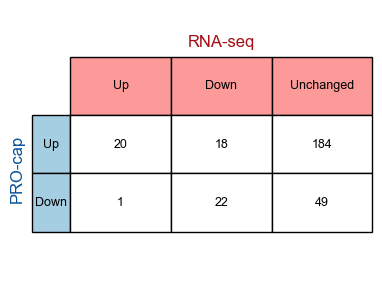

In [90]:
fig, ax = plt.subplots(figsize=(3,3.5))
ax.axis('off')
ax.axis('tight')

row_group, col_group = ["PRO-cap", "RNA-seq"]

colors = {"PRO-cap": "#a6cee3", "RNA-seq": "#fb9a99"}
rowColours=[colors[row_group]]*3
colColours=[colors[col_group]]*3
table = ax.table(cellText=results,
		  rowLabels=index,
		  rowColours=rowColours,
		  rowLoc="center",
		  colLabels=columns,
		  colColours=colColours,
		  colLoc="center",
		  cellLoc="center",
		  loc="center",
		  )
table.scale(1.3, 3.5)

table.auto_set_font_size(False)
for (row, col), cell in table.get_celld().items():
	if (row == 0) or (col == -1):
		cell.set_text_props(fontproperties=FontProperties(size=sfontsize))
	else:
		cell.set_text_props(fontproperties=FontProperties(size=sfontsize))

colors2 = {"PRO-cap": "#08519c", "RNA-seq": "#a50f15"}
ax.text(x=0, y=0.04, s=col_group, fontsize=bfontsize, ha="center", color=colors2[col_group])
ax.text(x=-0.1, y=-0.01, s=row_group, fontsize=bfontsize, va="center", rotation=90, color=colors2[row_group])

outputfile = f"{PROJECT_DIR_o}figures/SuppFig7b.pdf"
plt.savefig(outputfile, bbox_inches="tight", transparent=True) 